# Emergency Services Location Optimization

Facility Location Problems (FLP's) represent a complex, yet fundamental challenge within Data Science.  FLP's are frequently used for selecting the ideal location for a new retail store, distribution warehouse, restaurant, or emergency service station.  They must evaluate the demand, geographic location, as well as external factors such as budgetary constraints, real estate limitations, and traffic/transportation, to name a few.

Here, an FLP is performed to optimized the location of EMS Services and Fire Stations within Montgomery County, PA.  PuLP was used for Linear Programming with a CBC solver.  


In [1]:
# installing required packages

!pip install pulp geopandas folium shapely scikit-learn hdbscan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree
import pulp
import folium
from folium.plugins import MarkerCluster, HeatMap
from math import radians, cos, sin, asin, sqrt
from shapely.geometry import Point
import geopandas as gpd

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Reading in the data

df = pd.read_csv('/content/911.csv')
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [ ]:
# Obtaining the shape and looking at our columns

print(df.shape)
print(df.info())

(663522, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB
None


In [ ]:
# Looking at our unique emergencies

df['title'].unique()

array(['EMS: BACK PAINS/INJURY', 'EMS: DIABETIC EMERGENCY',
       'Fire: GAS-ODOR/LEAK', 'EMS: CARDIAC EMERGENCY', 'EMS: DIZZINESS',
       'EMS: HEAD INJURY', 'EMS: NAUSEA/VOMITING',
       'EMS: RESPIRATORY EMERGENCY', 'EMS: SYNCOPAL EPISODE',
       'Traffic: VEHICLE ACCIDENT -', 'EMS: VEHICLE ACCIDENT',
       'Traffic: DISABLED VEHICLE -', 'Fire: APPLIANCE FIRE',
       'EMS: GENERAL WEAKNESS', 'Fire: CARBON MONOXIDE DETECTOR',
       'EMS: UNKNOWN MEDICAL EMERGENCY', 'EMS: UNRESPONSIVE SUBJECT',
       'Fire: VEHICLE ACCIDENT', 'EMS: ALTERED MENTAL STATUS',
       'Fire: FIRE ALARM', 'EMS: CVA/STROKE',
       'Traffic: ROAD OBSTRUCTION -', 'EMS: SUBJECT IN PAIN',
       'EMS: HEMORRHAGING', 'EMS: FALL VICTIM', 'EMS: ASSAULT VICTIM',
       'EMS: SEIZURES', 'EMS: MEDICAL ALERT ALARM',
       'EMS: ABDOMINAL PAINS', 'Fire: PUMP DETAIL',
       'Fire: FIRE INVESTIGATION', 'EMS: OVERDOSE', 'EMS: MATERNITY',
       'EMS: UNCONSCIOUS SUBJECT', 'EMS: CHOKING', 'EMS: LACERATIONS',
     

## Model Preprocessing

In [ ]:
# make a copy
df2 = df.copy()

# label service type
df2['service'] = df2['title'].str.split(':').str[0].str.strip()  # 'EMS', 'Fire', 'Traffic', etc.
# keep only EMS and Fire for this analysis:
df_sf = df2[df2['service'].isin(['EMS', 'Fire'])].copy()

# convert timestamp to datetime if needed (optional: use recency weighting)
df_sf['timeStamp'] = pd.to_datetime(df_sf['timeStamp'], errors='coerce')
# Example recency weight: weight = 1 for all, or more recent events weighted higher
# Normalize timestamp to [0.5,1] for last 3 years etc. (optional)


In [ ]:
# Clustering the data for aggregation

def aggregate_by_kmeans(df_points, n_clusters=2000, random_state=42):
    coords = df_points[['lat','lng']].to_numpy()
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(coords)
    centroids = kmeans.cluster_centers_
    df_points['cluster'] = labels
    agg = df_points.groupby('cluster').agg(
        demand_count=('service','count'),
        lat=('lat','mean'),
        lng=('lng','mean')
    ).reset_index()
    return agg, centroids

# Example: aggregate separately
n_clusters_fire = 800
n_clusters_ems = 1200

fire_df = df_sf[df_sf['service']=='Fire']
ems_df = df_sf[df_sf['service']=='EMS']

fire_agg, fire_centroids = aggregate_by_kmeans(fire_df, n_clusters=n_clusters_fire)
ems_agg, ems_centroids = aggregate_by_kmeans(ems_df, n_clusters=n_clusters_ems)

# optionally combine into single demand DataFrame (and set weight by type)
fire_agg['service'] = 'Fire'
ems_agg['service'] = 'EMS'
demand_df = pd.concat([fire_agg, ems_agg], ignore_index=True)
demand_df['weight'] = demand_df['demand_count']  # you can scale EMS vs Fire differently


In [ ]:
# Creating Candidate Sites

# Use top demand nodes as candidate locations (or create additional candidate grid)
# Here we'll use the demand points themselves as candidates (simple)
candidates = demand_df[['lat','lng']].reset_index(drop=True)
candidates = candidates.rename(columns={'lat':'cand_lat','lng':'cand_lng'})
candidates['cand_id'] = candidates.index
demand_df['demand_id'] = demand_df.index


**Note, we are treating EMS and Fire as shared emergency services in this first pass through the model.  Later, we will break out the individual resources for a more granular view**

In [ ]:
# Building the Distance Determination Function

def haversine_array(lat1, lon1, lat2, lon2):
    # returns distance in kilometers
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

# build distance matrix between demand nodes and candidate sites
d_lats = demand_df['lat'].to_numpy()
d_lngs = demand_df['lng'].to_numpy()
c_lats = candidates['cand_lat'].to_numpy()
c_lngs = candidates['cand_lng'].to_numpy()

# compute matrix in kilometers; this may be large: n_demand x n_cands
# If dims are large, compute using efficient broadcasting in chunks
n_d = len(demand_df); n_c = len(candidates)
dist_mat = np.zeros((n_d, n_c))
for j in range(n_c):
    dist_mat[:, j] = haversine_array(d_lats, d_lngs, c_lats[j], c_lngs[j])


In [ ]:
# Required imports
from sklearn.neighbors import BallTree
import numpy as np
import pulp

# convert lat/lng to radians for BallTree haversine queries
def build_balltree(latitudes, longitudes):
    coords_rad = np.vstack([np.radians(latitudes), np.radians(longitudes)]).T
    return BallTree(coords_rad, metric='haversine')

# return top_k candidate indices and distances (in km) for each demand index
def topk_candidates_for_demands(demand_df, candidates, top_k=10):
    demand_coords = np.vstack([np.radians(demand_df['lat'].to_numpy()),
                               np.radians(demand_df['lng'].to_numpy())]).T
    cand_coords = np.vstack([np.radians(candidates['cand_lat'].to_numpy()),
                             np.radians(candidates['cand_lng'].to_numpy())]).T
    tree = BallTree(cand_coords, metric='haversine')
    # distances returned in radians; multiply by earth radius to get km
    dist_rad, idxs = tree.query(demand_coords, k=top_k)
    earth_km = 6371.0
    dist_km = dist_rad * earth_km
    return idxs, dist_km

# Sparse p-median solver: only create x[i,j] for allowed pairs (demand i, candidate j in top_k)
def solve_p_median_sparse(demand_df, candidates, idxs_allowed, dists_allowed, weights, p, solver_time_limit=None, threads=1):
    """
    idxs_allowed: shape (n_d, top_k) candidate indices
    dists_allowed: shape (n_d, top_k) distances (km)
    weights: 1D array length n_d
    """
    n_d = demand_df.shape[0]
    n_c = candidates.shape[0]
    top_k = idxs_allowed.shape[1]

    prob = pulp.LpProblem("p_median_sparse", pulp.LpMinimize)

    # y_j: open facility
    y = pulp.LpVariable.dicts('y', range(n_c), lowBound=0, upBound=1, cat='Binary')

    # x_i_k where k indexes the allowed candidate for demand i
    # we'll map x_vars[(i, local_k)] -> pulp variable
    x_vars = {}
    for i in range(n_d):
        for kk in range(top_k):
            j = int(idxs_allowed[i, kk])
            x_vars[(i, kk)] = pulp.LpVariable(f"x_{i}_{kk}", lowBound=0, upBound=1, cat='Binary')

    # objective: sum_i sum_k w_i * dist(i, j(i,k)) * x_i_k
    prob += pulp.lpSum(weights[i] * float(dists_allowed[i, kk]) * x_vars[(i, kk)]
                       for i in range(n_d) for kk in range(top_k))

    # each demand assigned to exactly one of its allowed candidates
    for i in range(n_d):
        prob += pulp.lpSum(x_vars[(i, kk)] for kk in range(top_k)) == 1

    # assignment implies facility open: x_i_k <= y_j
    for i in range(n_d):
        for kk in range(top_k):
            j = int(idxs_allowed[i, kk])
            prob += x_vars[(i, kk)] <= y[j]

    # exactly p facilities
    prob += pulp.lpSum(y[j] for j in range(n_c)) == p

    # solve with CBC; set timeLimit if provided
    solver = pulp.PULP_CBC_CMD(msg=True, timeLimit=solver_time_limit, threads=threads)
    prob.solve(solver)

    open_facilities = [j for j in range(n_c) if pulp.value(y[j]) > 0.5]

    # build assignment mapping to candidate index (global j)
    assignment = np.empty(n_d, dtype=int)
    for i in range(n_d):
        assigned_j = None
        for kk in range(top_k):
            if pulp.value(x_vars[(i, kk)]) > 0.5:
                assigned_j = int(idxs_allowed[i, kk])
                break
        assignment[i] = assigned_j if assigned_j is not None else -1

    return open_facilities, assignment, pulp.value(prob.objective)


## Running the LP algorithm

In [ ]:
# Running the calculation

# choose top_k small (3-20). Smaller top_k -> less memory, may slightly reduce solution quality.
top_k = 8
idxs_allowed, dists_allowed = topk_candidates_for_demands(demand_df, candidates, top_k=top_k)
weights = demand_df['weight'].to_numpy()

# sanity checks
n_d, n_c = demand_df.shape[0], candidates.shape[0]
print("n_demand:", n_d, "n_candidates:", n_c, "top_k:", top_k)
print("Estimated assignment variables:", n_d * top_k)

# solve
p = 10
open_fac, assignment, obj_val = solve_p_median_sparse(demand_df, candidates, idxs_allowed, dists_allowed, weights, p, solver_time_limit=300, threads=4)
print("Opened facilities:", len(open_fac), "objective:", obj_val)



n_demand: 2000 n_candidates: 2000 top_k: 8
Estimated assignment variables: 16000
Opened facilities: 86 objective: 678596.5514158003


In [ ]:
# Constructing the solver

def solve_set_cover(dist_mat, max_dist_km):
    n_d, n_c = dist_mat.shape
    prob = pulp.LpProblem("set_cover", pulp.LpMinimize)
    y = pulp.LpVariable.dicts('y', range(n_c), lowBound=0, upBound=1, cat='Binary')

    # objective: minimize number of open facilities
    prob += pulp.lpSum([y[j] for j in range(n_c)])

    # coverage constraints: for each demand i, at least one candidate within max_dist
    for i in range(n_d):
        cover_candidates = [j for j in range(n_c) if dist_mat[i,j] <= max_dist_km]
        if len(cover_candidates) == 0:
            # no candidate covers this demand within threshold; you could relax or flag these points
            prob += 0 >= 1  # infeasible; better to handle earlier
        else:
            prob += pulp.lpSum([y[j] for j in cover_candidates]) >= 1

    prob.solve()
    open_facilities = [j for j in range(n_c) if pulp.value(y[j]) > 0.5]
    return open_facilities, pulp.value(prob.objective)


## Running the CBC Solver to obtain how many facilities are needed

In [ ]:
# Running the Solver

max_dist_km = 5.0  # e.g., 5 km coverage threshold
open_facilities, n_open = solve_set_cover(dist_mat, max_dist_km)
print("Opened facilities:", len(open_facilities))


Opened facilities: 77


In [ ]:
# Viewing the facilities on a map

# center map on mean location
center_lat = df['lat'].mean()
center_lng = df['lng'].mean()
m = folium.Map(location=[center_lat, center_lng], zoom_start=10)  # adjust zoom

# add heatmap of all incidents (sample if huge)
sample = df_sf.sample(min(20000, len(df_sf)), random_state=1)  # sample for display speed
heat_data = sample[['lat','lng']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, min_opacity=0.2).add_to(m)

# show candidate sites (small dots)
for idx, row in candidates.iterrows():
    folium.CircleMarker([row['cand_lat'], row['cand_lng']], radius=2, fill=True, opacity=0.5).add_to(m)

# show selected open facilities larger
for j in open_fac:
    lat = candidates.loc[j, 'cand_lat']
    lng = candidates.loc[j, 'cand_lng']
    folium.Marker([lat,lng], popup=f'Facility {j}', icon=folium.Icon(color='red', icon='plus')).add_to(m)

# show demand cluster centroids colored by service
for _, r in demand_df.iterrows():
    color = 'blue' if r['service']=='EMS' else 'green'
    folium.CircleMarker([r['lat'], r['lng']], radius=3, color=color, fill=True, fill_opacity=0.6).add_to(m)

m.save('montgomery_facility_map.html')
print("Map saved to montgomery_facility_map.html")


Map saved to montgomery_facility_map.html


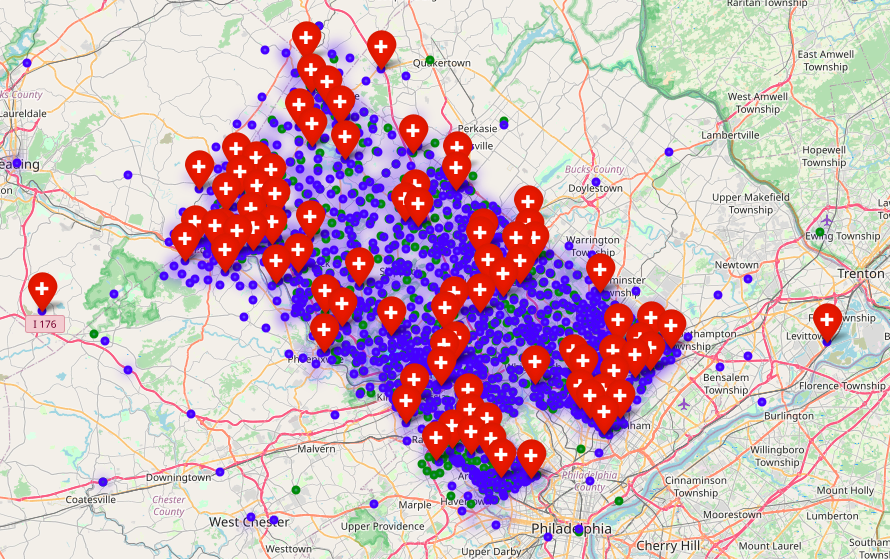




Above, we see that based on the constraints in our LP, we can build 77 service stations throughout Montgomery County based on geographic demand for emergency services.

Right now, we have treat EMS and Fire the same within the county, but now lets extend this to split up EMS and Fire Stations, and limit our ability to add 50 new stations.

## Optimized code to break out EMS and Fire Services


In [ ]:
# ------------------ IMPORTS ------------------
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree
import pulp
from math import radians
import folium
from folium.plugins import HeatMap

pd.options.mode.chained_assignment = None  # silence warnings

# ------------------ HELPERS ------------------

def downcast_df(df):
    """Downcast numeric columns to reduce memory."""
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

def aggregate_by_kmeans(df_points, n_clusters=50, random_state=42):
    """Aggregate demand points using KMeans."""
    coords = df_points[['lat','lng']].to_numpy()
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(coords)
    df_points = df_points.copy()
    df_points['cluster'] = labels
    agg = df_points.groupby('cluster').agg(
        demand_count=('service','count'),
        lat=('lat','mean'),
        lng=('lng','mean')
    ).reset_index()
    return downcast_df(agg), kmeans.cluster_centers_

def haversine_array(lat1, lon1, lat2, lon2):
    """Haversine distance in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2*R*np.arcsin(np.sqrt(a))

def topk_candidates_for_demands(demand_df, cand_df, top_k=8):
    """Find top-k candidate indices and distances using BallTree."""
    demand_coords = np.vstack([np.radians(demand_df['lat'].to_numpy()),
                               np.radians(demand_df['lng'].to_numpy())]).T
    cand_coords = np.vstack([np.radians(cand_df['cand_lat'].to_numpy()),
                             np.radians(cand_df['cand_lng'].to_numpy())]).T
    tree = BallTree(cand_coords, metric='haversine')
    dist_rad, idxs = tree.query(demand_coords, k=top_k)
    return idxs, dist_rad * 6371.0  # km

def solve_p_median_sparse(idxs_allowed, dists_allowed, weights, p, time_limit=None, threads=1):
    """Sparse p-median solver using PuLP."""
    n_d, top_k = idxs_allowed.shape
    n_c = int(idxs_allowed.max()) + 1
    prob = pulp.LpProblem("p_median_sparse", pulp.LpMinimize)

    y = pulp.LpVariable.dicts('y', range(n_c), lowBound=0, upBound=1, cat='Binary')
    x_vars = {(i, kk): pulp.LpVariable(f"x_{i}_{kk}", lowBound=0, upBound=1, cat='Binary')
              for i in range(n_d) for kk in range(top_k)}

    prob += pulp.lpSum(weights[i] * float(dists_allowed[i, kk]) * x_vars[(i, kk)]
                       for i in range(n_d) for kk in range(top_k))

    for i in range(n_d):
        prob += pulp.lpSum(x_vars[(i, kk)] for kk in range(top_k)) == 1
        for kk in range(top_k):
            j = int(idxs_allowed[i, kk])
            prob += x_vars[(i, kk)] <= y[j]

    prob += pulp.lpSum(y[j] for j in range(n_c)) <= p

    solver = pulp.PULP_CBC_CMD(msg=True, timeLimit=time_limit, threads=threads)
    prob.solve(solver)

    open_facilities = [j for j in range(n_c) if pulp.value(y[j]) > 0.5]
    assignment = np.array([
        next((int(idxs_allowed[i, kk]) for kk in range(top_k) if pulp.value(x_vars[(i, kk)]) > 0.5), -1)
        for i in range(n_d)
    ], dtype=int)

    return open_facilities, assignment, pulp.value(prob.objective)

def coverage_metrics_fast(demand_df, cand_df, open_ids, weights_col='weight'):
    """Compute coverage metrics using only open facilities."""
    d_lats = demand_df['lat'].to_numpy()
    d_lngs = demand_df['lng'].to_numpy()
    c_lats = cand_df.loc[open_ids, 'cand_lat'].to_numpy()
    c_lngs = cand_df.loc[open_ids, 'cand_lng'].to_numpy()
    assigned_dist = np.full(len(demand_df), np.inf, dtype='float32')

    for j in range(len(c_lats)):
        dist = haversine_array(d_lats, d_lngs, c_lats[j], c_lngs[j])
        assigned_dist = np.minimum(assigned_dist, dist)

    w = demand_df[weights_col].to_numpy()
    metrics = {
        "avg_weighted_distance_km": float((assigned_dist * w).sum() / w.sum()),
        "pct_within_1km": float(100 * w[assigned_dist <= 1].sum() / w.sum()),
        "pct_within_2km": float(100 * w[assigned_dist <= 2].sum() / w.sum()),
        "pct_within_5km": float(100 * w[assigned_dist <= 5].sum() / w.sum()),
    }
    return metrics

def assigned_counts(assignment, candidates, open_sites):
    """Compute assigned demand counts per open facility."""
    s = pd.Series(assignment)
    s = s[s != -1]
    cand = candidates.set_index("cand_id")
    result = s.value_counts().rename("assigned_demand_points").to_frame()
    result["lat"] = cand.loc[result.index, "cand_lat"].values
    result["lng"] = cand.loc[result.index, "cand_lng"].values
    result["is_open"] = result.index.isin(open_sites)
    return result.reset_index().rename(columns={'index':'cand_id'})

def generate_coverage_points(cand_df, radius_km=5, step_m=400):
    """Generate points around open stations for coverage heatmap."""
    pts = []
    r_deg = radius_km / 111.0
    g = step_m / 111000.0
    for _, row in cand_df.iterrows():
        lat0, lng0 = row['cand_lat'], row['cand_lng']
        lat_range = np.arange(lat0 - r_deg, lat0 + r_deg, g)
        lng_range = np.arange(lng0 - r_deg, lng0 + r_deg, g)
        for lat in lat_range:
            for lng in lng_range:
                if haversine_array(lat0, lng0, lat, lng) <= radius_km:
                    pts.append((lat, lng))
    return pts

# ------------------ PARAMETERS ------------------
n_clusters_ems = 50    # close to p_limit
n_clusters_fire = 50
top_k = 8
p_limit = 50
random_state = 42

# ------------------ DATA PREP ------------------
fire_df = df_sf[df_sf['service']=='Fire'].copy()
ems_df  = df_sf[df_sf['service']=='EMS'].copy()
print("Counts: EMS events:", len(ems_df), " Fire events:", len(fire_df))

fire_agg, _ = aggregate_by_kmeans(fire_df, n_clusters=n_clusters_fire, random_state=random_state)
ems_agg, _  = aggregate_by_kmeans(ems_df, n_clusters=n_clusters_ems, random_state=random_state)

fire_agg['service'], ems_agg['service'] = 'Fire','EMS'
fire_agg['weight'], ems_agg['weight'] = fire_agg['demand_count'], ems_agg['demand_count']

ems_candidates = ems_agg[['lat','lng']].rename(columns={'lat':'cand_lat','lng':'cand_lng'}).reset_index(drop=True)
fire_candidates = fire_agg[['lat','lng']].rename(columns={'lat':'cand_lat','lng':'cand_lng'}).reset_index(drop=True)
ems_candidates['cand_id'], fire_candidates['cand_id'] = np.arange(len(ems_candidates)), np.arange(len(fire_candidates))

ems_demand, fire_demand = ems_agg.reset_index(drop=True), fire_agg.reset_index(drop=True)

# ------------------ TOP-K CANDIDATES ------------------
idxs_ems, dists_ems = topk_candidates_for_demands(ems_demand, ems_candidates, top_k=top_k)
idxs_fire, dists_fire = topk_candidates_for_demands(fire_demand, fire_candidates, top_k=top_k)

# ------------------ P-MEDIAN SOLVE ------------------
open_ems, assign_ems, obj_ems = solve_p_median_sparse(
    idxs_ems, dists_ems, ems_demand['weight'].to_numpy(), p=p_limit, time_limit=600, threads=4
)
open_fire, assign_fire, obj_fire = solve_p_median_sparse(
    idxs_fire, dists_fire, fire_demand['weight'].to_numpy(), p=p_limit, time_limit=600, threads=4
)
print("EMS: opened", len(open_ems), "objective:", obj_ems)
print("Fire: opened", len(open_fire), "objective:", obj_fire)

# ------------------ COVERAGE METRICS ------------------
ems_metrics = coverage_metrics_fast(ems_demand, ems_candidates, open_ems)
fire_metrics = coverage_metrics_fast(fire_demand, fire_candidates, open_fire)
print("EMS coverage metrics:", ems_metrics)
print("Fire coverage metrics:", fire_metrics)

# ------------------ ASSIGNED COUNTS ------------------
ems_assign_counts = assigned_counts(assign_ems, ems_candidates, open_ems)
fire_assign_counts = assigned_counts(assign_fire, fire_candidates, open_fire)

# ------------------ FOLIUM MAP ------------------
center_lat, center_lng = df_sf['lat'].mean(), df_sf['lng'].mean()
m = folium.Map(location=[center_lat, center_lng], zoom_start=10)

# base demand heatmap (sampled)
sample_all = df_sf[['lat','lng']].sample(min(20000, len(df_sf)), random_state=1)
HeatMap(sample_all.values.tolist(), radius=8, blur=12, name="Demand Heatmap").add_to(m)

# selected EMS/Fire stations
for _, r in ems_candidates.loc[open_ems].iterrows():
    folium.CircleMarker([r['cand_lat'], r['cand_lng']], radius=6, color='blue', fill=True,
                        popup='EMS site', tooltip='EMS').add_to(m)
for _, r in fire_candidates.loc[open_fire].iterrows():
    folium.CircleMarker([r['cand_lat'], r['cand_lng']], radius=6, color='red', fill=True,
                        popup='Fire site', tooltip='Fire').add_to(m)

# coverage heatmaps (5 km)
ems_cover_pts = generate_coverage_points(ems_candidates.loc[open_ems], radius_km=5)
fire_cover_pts = generate_coverage_points(fire_candidates.loc[open_fire], radius_km=5)
HeatMap(ems_cover_pts, name="EMS 5km Coverage", radius=15, blur=18).add_to(m)
HeatMap(fire_cover_pts, name="Fire 5km Coverage", radius=15, blur=18).add_to(m)

folium.LayerControl().add_to(m)
m.save('ems_fire_selected_sites_map.html')
print("Map saved to ems_fire_selected_sites_map.html")


Counts: EMS events: 332692  Fire events: 100622
EMS: opened 50 objective: 0.0
Fire: opened 50 objective: 0.0
EMS coverage metrics: {'avg_weighted_distance_km': 0.0, 'pct_within_1km': 100.0, 'pct_within_2km': 100.0, 'pct_within_5km': 100.0}
Fire coverage metrics: {'avg_weighted_distance_km': 0.0, 'pct_within_1km': 100.0, 'pct_within_2km': 100.0, 'pct_within_5km': 100.0}
Map saved to ems_fire_selected_sites_map.html


We have optimized construction of 50 new EMS and Fire stations within the county:

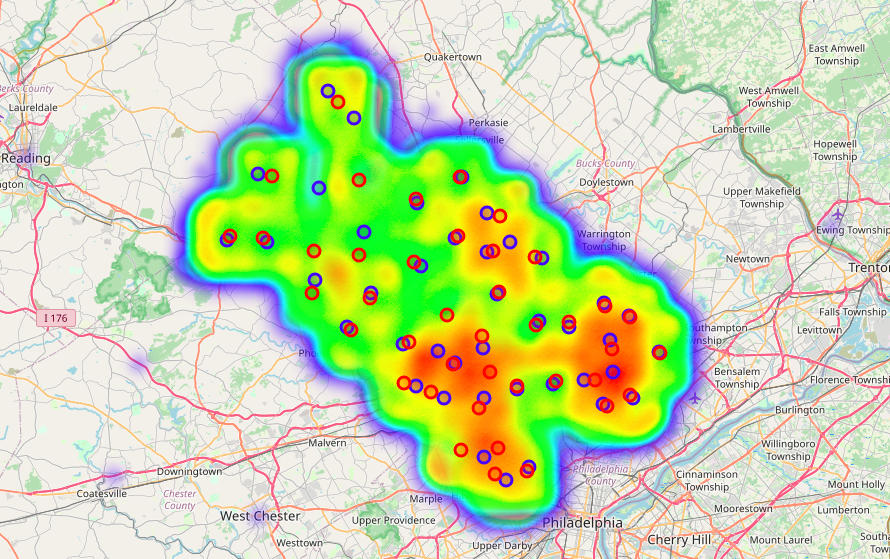

**Based on the heatmap plot of Montgomery County, we have the following insights:**

* Southeastern MontCo has far greater demand for emergency services compared to Northern MontCo

* It would be beneficial to have some selected Fire Stations share services with EMS

* Here, we limited the number of new stations to 50, depending on budgetary limitations, and based on geographic distance of some stations, this number could certainly be reduced, and still provide better emergency service compared to current situation.